# Building a Supply Chain Knowledge Graph at Scale

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t`

> **Neo4j required**: The checked-in Qwen2.5 extraction cache is the default
> production input, and the default path needs no GPU:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/02_supply_chain_kg_construction.py
> ```
> Set `RERUN_EXTRACTION=True` to rebuild the cache, which does need a CUDA GPU and
> the `ml4t-gpu` image.


This notebook demonstrates large-scale knowledge graph construction from SEC 10-K
filings, extracting supply chain and competitive relationships from S&P 100 companies
and loading them into a Neo4j graph database.

**Learning Objectives**:
- Build a relationship extraction pipeline using a local LLM (Qwen2.5-7B-Instruct)
- Design an entity resolution step to normalize names across filings
- Load extracted triples into Neo4j using efficient batch UNWIND queries
- Visualize supply chain concentration risk as a network graph

**Book Reference**: Chapter 23, Section 23.2 (Constructing Financial Knowledge Graphs)

**Prerequisites**: Run `01_sp100_sec_download` first to download the SEC filings.
Requires a live Neo4j instance. Cache regeneration additionally requires an RTX-class GPU.

In [1]:
"""Extract supply-chain relationships from SEC 10-K filings."""

from __future__ import annotations

import hashlib
import json
import logging
import os
import re
import tempfile
import time
from collections import Counter
from collections.abc import Generator
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import torch

from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
# Production defaults. Papermill overrides them for testing.
# The staged SP100 10-K corpus ships with 601 filings across 101 companies, 2020-2025.
# MAX_COMPANIES caps the companies sent through the LLM when RERUN_EXTRACTION is True,
# keeping every filing of the alphabetically first N symbols. It does nothing on the
# cached path: those triples were extracted from the whole corpus.
MAX_COMPANIES = 0
LLM_BATCH_SIZE = 2  # Texts per GPU batch (Qwen2.5-7B uses ~14GB; 2 leaves headroom on 24GB)
RERUN_EXTRACTION = False  # Set True to force LLM re-extraction; False loads cached triples

# Local HuggingFace checkpoint used only for explicit cache regeneration.
#   Default: Qwen/Qwen2.5-7B-Instruct (fp16 ~14 GB, fits 24 GB GPU comfortably).
#   Alt:     Qwen/Qwen3-8B            (fp16 ~16 GB; native thinking mode).
# Set ENABLE_THINKING=True only with a Qwen3 family model; Qwen2.5 ignores it.
# Bump MAX_NEW_TOKENS to ~2048 when ENABLE_THINKING=True (CoT eats tokens).
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
ENABLE_THINKING = False
MAX_NEW_TOKENS = 512
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Infrastructure Detection

Automatically detect GPU and Neo4j availability.

In [4]:
GPU_AVAILABLE = torch.cuda.is_available()
print(f"GPU available: {GPU_AVAILABLE}")
if GPU_AVAILABLE:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Neo4j connection
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

from neo4j import GraphDatabase

NEO4J_DRIVER = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
NEO4J_DRIVER.verify_connectivity()
print(f"Neo4j connected: {NEO4J_URI}")

GPU available: False


Neo4j connected: bolt://neo4j:7687


## 2. Load LLM for Batch Extraction

Load Qwen2.5-7B-Instruct for relationship extraction. The model stays in memory
for efficient batch processing.

In [5]:
LLM_MODEL = None
LLM_TOKENIZER = None
BATCH_SIZE = LLM_BATCH_SIZE

_cache_path = get_chapter_dir(23) / "output" / "supply_chain_cache" / "extracted_triples.parquet"
_need_llm = RERUN_EXTRACTION or not _cache_path.exists()

if _need_llm and GPU_AVAILABLE:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    try:
        print(f"Loading {MODEL_NAME} for batch extraction...")
        # MODEL_NAME comes from the parameters cell (overridable via Papermill).
        LLM_TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side="left")
        if LLM_TOKENIZER.pad_token is None:
            LLM_TOKENIZER.pad_token = LLM_TOKENIZER.eos_token

        LLM_MODEL = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            dtype=torch.float16,
            device_map="cuda",
        )
        print(f"Model loaded: {MODEL_NAME}")
        print(f"Batch size: {BATCH_SIZE}")
    except Exception as e:
        raise RuntimeError(f"Could not load {MODEL_NAME} on CUDA") from e
elif not _need_llm:
    print("Using the validated extraction cache; Qwen is not loaded")
else:
    raise RuntimeError("Cache regeneration requires a CUDA GPU")

Using the validated extraction cache; Qwen is not loaded


## 3. Data Loading

Load pre-downloaded S&P 100 filings from the download script. The notebook now
requires real staged filings instead of falling back to a demo dataset.

In [6]:
from data import load_sec_filings

In [7]:
filings_df = load_sec_filings("10-K", universe="sp100")
required_filing_columns = {
    "symbol",
    "company_name",
    "form",
    "filing_date",
    "accession_no",
    "year",
    "text",
    "text_length",
}
assert required_filing_columns <= set(filings_df.columns)
assert filings_df.filter(
    pl.any_horizontal(pl.col(list(required_filing_columns)).is_null())
).is_empty()
assert filings_df.select(pl.struct(["symbol", "accession_no"]).is_duplicated().sum()).item() == 0
assert filings_df.filter(pl.col("text").str.len_chars() != pl.col("text_length")).is_empty()
print(f"Loaded {len(filings_df)} 10-K filings via load_sec_filings()")

# Subsample for tractable Qwen runtime, but only when the LLM is the source of the
# triples. On the cached path the committed triples came from the whole corpus, so
# subsampling here would relabel every figure with a corpus that produced none of them.
if MAX_COMPANIES > 0 and RERUN_EXTRACTION:
    keep = sorted(filings_df["symbol"].unique().to_list())[:MAX_COMPANIES]
    filings_df = filings_df.filter(pl.col("symbol").is_in(keep))
    print(
        f"Subset to MAX_COMPANIES={MAX_COMPANIES}: {len(filings_df)} filings "
        f"across {filings_df['symbol'].n_unique()} companies"
    )
elif MAX_COMPANIES > 0:
    print(
        f"MAX_COMPANIES={MAX_COMPANIES} ignored: RERUN_EXTRACTION is False, and the "
        "cached triples were extracted from the full corpus"
    )

# Show summary
print(f"\nCompanies: {filings_df['symbol'].n_unique()}")
print(f"Filings: {len(filings_df)}")
if "year" in filings_df.columns:
    years = filings_df["year"].unique().sort().to_list()
    print(f"Years: {years}")

Loaded 601 10-K filings via load_sec_filings()

Companies: 101
Filings: 601
Years: [2020, 2021, 2022, 2023, 2024, 2025]


## 4. Relationship Schema

Define the knowledge graph schema. Each extracted relationship is a
subject-predicate-object triple restricted to three financial relationship types.

### Triple Dataclass

Lightweight container for a single knowledge graph edge. The `to_dict()` method
enables batch serialization for Neo4j UNWIND loading.

In [8]:
@dataclass
class Triple:
    """A subject-predicate-object relationship."""

    subject: str
    predicate: str
    object: str

    def to_dict(self) -> dict:
        return {"subject": self.subject, "predicate": self.predicate, "object": self.object}

In [9]:
RELATIONSHIP_TYPES = ["HAS_SUPPLIER", "COMPETES_WITH", "HAS_CUSTOMER"]

EXTRACTION_PROMPT = """You are a financial analyst extracting business relationships from SEC 10-K filings.

Extract ONLY the following relationship types:
1. HAS_SUPPLIER: Company depends on another entity for components/services
2. COMPETES_WITH: Company competes with another entity in a market
3. HAS_CUSTOMER: Company sells to another entity (if mentioned)

Output format: JSON array of objects with keys "subject", "predicate", "object"
- subject: The company name (use full official name)
- predicate: One of HAS_SUPPLIER, COMPETES_WITH, HAS_CUSTOMER
- object: The related entity name (abbreviated, e.g., "TSMC" not full name)

RULES:
- Extract ONLY explicitly stated relationships
- Entity names should be ≤5 words
- Normalize common names (TSMC, Foxconn, Samsung, etc.)

Example:
[{"subject": "Apple Inc.", "predicate": "HAS_SUPPLIER", "object": "TSMC"}]
"""

## 5. Batch LLM Extraction

Process multiple documents in parallel for higher throughput. The pipeline sends
batches of filing texts through the LLM in a single forward pass, then parses
the JSON output into structured triples.

### Batch Extraction Function

Core extraction function that sends multiple filing texts through the LLM in one
batched forward pass.

### Prompt Builder

Construct a chat-formatted prompt for one filing so the batch extraction cell
can stay focused on tokenization, generation, and JSON parsing.

In [10]:
def build_batch_prompt(text: str, company_name: str) -> str:
    """Create the chat-formatted extraction prompt for one filing."""
    user_prompt = f"""Company: {company_name}

SEC 10-K Filing Text:
{text[:6000]}

Extract all business relationships. Output ONLY valid JSON array."""
    messages = [
        {"role": "system", "content": EXTRACTION_PROMPT},
        {"role": "user", "content": user_prompt},
    ]
    # Qwen2.5 ignores enable_thinking; Qwen3 uses it when explicitly selected.
    return LLM_TOKENIZER.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=ENABLE_THINKING,
    )

### Batch Extraction Function

Send a batch of prompts through the LLM, decode the generated text, and parse
each response into structured triples.

In [11]:
def extract_relationships_batch(texts: list[str], company_names: list[str]) -> list[list[Triple]]:
    """
    Extract relationships from multiple texts in a single batch.

    Uses batched generation for efficient GPU utilization.
    """
    if LLM_MODEL is None or LLM_TOKENIZER is None:
        raise RuntimeError(
            "GPU-backed Qwen2.5-7B extraction is required. The sample-triple "
            "fallback has been removed."
        )

    model_inputs = LLM_TOKENIZER(
        [
            build_batch_prompt(text, company_name)
            for text, company_name in zip(texts, company_names, strict=False)
        ],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=4096,
    ).to("cuda")

    with torch.no_grad():
        generated_ids = LLM_MODEL.generate(
            **model_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=LLM_TOKENIZER.pad_token_id,
        )

    # Decode responses
    results = []
    for i, (input_ids, output_ids) in enumerate(
        zip(model_inputs.input_ids, generated_ids, strict=False)
    ):
        # Get only generated tokens
        generated = output_ids[len(input_ids) :]
        response = LLM_TOKENIZER.decode(generated, skip_special_tokens=True)

        # Parse JSON
        triples = _parse_json_triples(response, company_names[i])
        results.append(triples)

    return results

### JSON Response Parser

Extract the JSON array from LLM output, handling common formatting issues
(preamble text, trailing content). Only keeps triples with valid predicate types.

In [12]:
def _parse_json_triples(response: str, company_name: str) -> list[Triple]:
    """Parse JSON response into Triple objects."""
    # Strip Qwen3 thinking blocks if present (Qwen2.5 never emits them).
    response = re.sub(r"<think>.*?</think>", "", response, flags=re.DOTALL).strip()
    try:
        start_idx = response.find("[")
        end_idx = response.rfind("]") + 1
        if start_idx >= 0 and end_idx > start_idx:
            json_str = response[start_idx:end_idx]
            extracted = json.loads(json_str)
            return [
                Triple(
                    subject=item.get("subject", company_name),
                    predicate=item.get("predicate", ""),
                    object=item.get("object", ""),
                )
                for item in extracted
                if item.get("predicate") in RELATIONSHIP_TYPES
            ]
    except (json.JSONDecodeError, KeyError):
        pass
    return []

### Batch Iterator Utility

Simple chunking helper for processing filings in GPU-friendly batch sizes.

In [13]:
def batched(iterable, n: int) -> Generator:
    """Yield successive n-sized chunks from iterable."""
    items = list(iterable)
    for i in range(0, len(items), n):
        yield items[i : i + n]

## 6. Extract Relationships

The preserved producer run processed 601 filings through Qwen2.5-7B-Instruct
in batches of 2. It took about 27 minutes on an NVIDIA RTX 3090 and used
roughly 14 GB of VRAM. CPU regeneration is not a supported production path.

**Pre-computed cache**: The repository ships a cached extraction result
(`output/supply_chain_cache/extracted_triples.parquet`, 11KB) derived from
public SEC EDGAR 10-K filings. Its Parquet bytes and sidecar metadata were
committed with the full producer artifact. This lets you explore the graph analysis,
Neo4j loading, and visualization sections without a GPU.

To run the full LLM extraction yourself:
```python
RERUN_EXTRACTION = True  # in the parameters cell above
```

A sidecar `extracted_triples.meta.json` pins the parquet's content hash,
schema, row count, and extractor identity. Reads recompute the hash and
fail if the cache has drifted from the recorded producer output.

In [14]:
EXPECTED_CACHE_COLUMNS = ("subject", "predicate", "object")
CACHE_ROWS_MIN = 100
CACHE_ROWS_MAX = 50_000


def _hash_cache_bytes(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

### Cache Validator

Validate the cache bytes, schema, and row count before constructing graph edges.

In [15]:
def _validate_cache(parquet_path: Path, meta_path: Path) -> pl.DataFrame:
    if not meta_path.exists():
        raise FileNotFoundError(
            f"Cache parquet exists but {meta_path.name} is missing. "
            "Delete the parquet or set RERUN_EXTRACTION=True to regenerate both."
        )
    meta = json.loads(meta_path.read_text())
    current_hash = _hash_cache_bytes(parquet_path)
    if current_hash != meta["content_hash"]:
        raise ValueError(
            f"Cache hash mismatch for {parquet_path.name}: "
            f"file={current_hash[:16]}, meta={meta['content_hash'][:16]}. "
            "Delete both files or set RERUN_EXTRACTION=True."
        )
    df = pl.read_parquet(parquet_path)
    if tuple(df.columns) != EXPECTED_CACHE_COLUMNS:
        raise ValueError(
            f"Cache schema drift: columns={df.columns}, expected={list(EXPECTED_CACHE_COLUMNS)}."
        )
    n_rows = df.height
    if not (CACHE_ROWS_MIN <= n_rows <= CACHE_ROWS_MAX):
        raise ValueError(
            f"Cache row count {n_rows} outside plausible range "
            f"[{CACHE_ROWS_MIN}, {CACHE_ROWS_MAX}]."
        )
    if n_rows != meta["row_count"]:
        raise ValueError(
            f"Cache row count {n_rows} disagrees with meta row_count {meta['row_count']}."
        )
    return df

### Cache Metadata Writer

Record the exact extraction identity whenever regeneration is explicitly enabled.

In [16]:
def _write_cache_meta(parquet_path: Path, meta_path: Path, n_rows: int) -> None:
    meta = {
        "content_hash": _hash_cache_bytes(parquet_path),
        "schema": list(EXPECTED_CACHE_COLUMNS),
        "row_count": n_rows,
        "model_name": MODEL_NAME,
        "max_companies": MAX_COMPANIES,
        "written_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    }
    meta_path.write_text(json.dumps(meta, indent=2))

### Extraction Runner

Regenerate all candidate triples only when the parameter explicitly requests it.

In [17]:
def run_full_extraction(filing_records: list[dict]) -> tuple[list[Triple], float]:
    """Run deterministic batch extraction with visible progress."""
    started = time.time()
    extracted: list[Triple] = []
    n_batches = (len(filing_records) + BATCH_SIZE - 1) // BATCH_SIZE
    for batch_idx, batch in enumerate(batched(filing_records, BATCH_SIZE)):
        texts = [record["text"][:6000] for record in batch]
        names = [record["company_name"] for record in batch]
        batch_results = extract_relationships_batch(texts, names)
        for triples in batch_results:
            extracted.extend(triples)
        elapsed = time.time() - started
        rate = (batch_idx + 1) / elapsed if elapsed else 0.0
        remaining = (n_batches - batch_idx - 1) / rate if rate else 0.0
        print(
            f"Batch {batch_idx + 1}/{n_batches}: {len(batch)} filings, "
            f"{sum(map(len, batch_results))} relationships, {len(extracted)} total "
            f"[{elapsed:.0f}s elapsed, about {remaining:.0f}s remaining]",
            flush=True,
        )
        torch.cuda.empty_cache()
    return extracted, time.time() - started

In [18]:
CACHE_DIR = get_chapter_dir(23) / "output" / "supply_chain_cache"
CACHE_PATH = CACHE_DIR / "extracted_triples.parquet"
CACHE_META_PATH = CACHE_DIR / "extracted_triples.meta.json"

if not RERUN_EXTRACTION:
    cached_df = _validate_cache(CACHE_PATH, CACHE_META_PATH)
    CACHE_META = json.loads(CACHE_META_PATH.read_text())
    all_triples = [
        Triple(r["subject"], r["predicate"], r["object"]) for r in cached_df.iter_rows(named=True)
    ]
    extraction_elapsed = None
    # MODEL_NAME says what would run, not what did: the cache carries its own
    # producer, and overriding the parameter cannot retroactively change it.
    EXTRACTOR_NAME = CACHE_META["model_name"]
    CACHE_CONTENT_HASH = CACHE_META["content_hash"]
    print(f"Loaded and validated {len(all_triples)} cached triples from {CACHE_PATH.name}")
    print(f"Cache producer: {EXTRACTOR_NAME}, {CACHE_META['row_count']} rows")
    # Narrow to the cohort the producer recorded. A cache regenerated with
    # MAX_COMPANIES set covers part of the corpus, and the roster and figures
    # below have to describe the filings the triples came from.
    CACHE_SCOPE = int(CACHE_META.get("max_companies", 0) or 0)
    if CACHE_SCOPE:
        cached_symbols = sorted(filings_df["symbol"].unique().to_list())[:CACHE_SCOPE]
        filings_df = filings_df.filter(pl.col("symbol").is_in(cached_symbols))
        years = filings_df["year"].unique().sort().to_list()
        print(
            f"Cache covers MAX_COMPANIES={CACHE_SCOPE}: narrowed to {len(filings_df)} "
            f"filings across {filings_df['symbol'].n_unique()} companies"
        )
else:
    all_triples, extraction_elapsed = run_full_extraction(filings_df.to_dicts())
    cache_df = pl.DataFrame([triple.to_dict() for triple in all_triples])
    cache_df.write_parquet(CACHE_PATH)
    _write_cache_meta(CACHE_PATH, CACHE_META_PATH, len(all_triples))
    EXTRACTOR_NAME = MODEL_NAME
    CACHE_CONTENT_HASH = _hash_cache_bytes(CACHE_PATH)
    print(f"Regenerated {len(all_triples)} triples in {extraction_elapsed:.1f}s")

Loaded and validated 2049 cached triples from extracted_triples.parquet
Cache producer: Qwen/Qwen2.5-7B-Instruct, 2049 rows


## 7. Entity Resolution

The extraction prompt hands the model the filer's name and asks it to repeat that
name as the subject. It comes back unchanged for 51 of the 133 distinct subject
strings in the cache. Another 61 are the same registrant re-cased, re-punctuated or
word-order swapped, and 21 name something else, usually an operating subsidiary or
a brand. Each spelling is a separate node unless something merges them, and every
degree count downstream is then measured on the fragments.

Two things resolve names here. A canonical key strips case, punctuation, corporate
suffixes and word order, so all spellings of one name collapse onto one node. The
key is then looked up in the roster of S&P 100 filers built from the corpus itself,
and a match takes the filer's official name. That second step is what makes a
company named as somebody's competitor the same node as the company that filed its
own 10-K.

### Canonical Entity Key

The join key for every name in the graph. Sorting the surviving tokens is what
merges `SCHWAB CHARLES CORP` with `The Charles Schwab Corporation`; it is the only
rule here that can merge names with different word order, and on this cache it
merges exactly one group, the four spellings of that company.

In [19]:
CORPORATE_SUFFIXES = frozenset(
    {
        "inc",
        "incorporated",
        "corp",
        "corporation",
        "co",
        "cos",
        "company",
        "companies",
        "plc",
        "ltd",
        "limited",
        "lp",
        "llc",
        "holdings",
        "holding",
        "group",
        "the",
        "nv",
        "sa",
        "ag",
        "new",
        "del",
        "de",
    }
)


def entity_key(name: str) -> str:
    """Canonical join key: case, punctuation, corporate suffix and word order removed."""
    stripped = re.sub(r"[^a-z0-9]+", " ", name.lower())
    tokens = [token for token in stripped.split() if token not in CORPORATE_SUFFIXES]
    return " ".join(sorted(tokens or stripped.split()))


def normalize_entity_text(name: str) -> str:
    """Collapse whitespace and strip trailing punctuation from extracted names."""
    return " ".join(name.split()).strip(" ,.;:")

### Filer Roster

The corpus knows the official name of every company whose filings were extracted,
so the subject of a triple is not a name that has to be guessed at. Alphabet files
under two symbols with one name, which is why the roster is keyed on the name.

In [20]:
FILER_ROSTER: dict[str, str] = {}
for filer_name in sorted(set(filings_df["company_name"].to_list())):
    FILER_ROSTER.setdefault(entity_key(filer_name), filer_name)
assert len(FILER_ROSTER) == len(set(filings_df["company_name"].to_list())), (
    "two filers share a canonical key; the roster cannot resolve between them"
)
print(f"Filer roster: {len(FILER_ROSTER)} issuers from {filings_df['symbol'].n_unique()} symbols")

Filer roster: 100 issuers from 101 symbols


### Entity Alias Map

Short forms for entities that never file with the SEC, so the roster cannot reach
them. The extraction prompt already tells the model to emit `TSMC` rather than the
full legal name, and the hit counts printed below show what that leaves for the
alias map to do.

In [21]:
ENTITY_ALIASES = {
    "Taiwan Semiconductor Manufacturing Company": "TSMC",
    "Taiwan Semiconductor": "TSMC",
    "Foxconn Technology Group": "Foxconn",
    "Hon Hai Precision": "Foxconn",
    "Samsung Electronics": "Samsung",
    "SK Hynix": "SK Hynix",
    "Hynix": "SK Hynix",
    "Advanced Micro Devices": "AMD",
    "Amazon Web Services": "AWS",
    "Microsoft Azure": "Azure",
}
ALIAS_BY_KEY = {entity_key(variant): standard for variant, standard in ENTITY_ALIASES.items()}
assert len(ALIAS_BY_KEY) == len(ENTITY_ALIASES), "two aliases collapse onto one canonical key"

### Generic Entity Filter

Reject category phrases that do not identify a company or organization. The filter
matches on the canonical key rather than the raw string, so a phrase cannot escape
it by arriving in a different case or with a hyphen the list does not carry.

In [22]:
# Generic category phrases are not named graph entities. A pipe-delimited string
# keeps this reader-facing configuration compact.
GENERIC_ENTITY_NAMES = """
aluminum suppliers|broadcast station group|broadcast station groups|composite suppliers
media corporation|media corporations|numerous suppliers|restaurants|third party suppliers
unaffiliated third party suppliers|consumers|third parties|third party|third-party
third-party manufacturer|third-party manufacturers|third-party tower operators
financial institutions|financial institution|governments|government|government agencies
distributors|wholesale distributors|vendors|wholesalers|travelers|hospitals|merchants
leaf merchants|domestic tobacco growers|fintechs|businesses|pharmaceutical companies
manufacturers|sensor manufacturers|electronics|electronics manufacturing service providers
travel service providers|enterprises|banks|airlines|routers|infrastructure equipment
insurance company clients|academic|energy|healthcare|semiconductor|hd mapping companies
sellers|buyers|startups|suppliers|research and industrial|food & beverage|power & renewables
agricultural|grapes|patients and communities|business and general aviation aircraft operators
mobile providers|other multichannel video providers|digital messaging and payment platforms
high-frequency stores|3000+ small businesses|small, minority- and women-owned businesses
construction, earthmoving, material handling, roadbuilding, and/or forestry equipment locations
""".strip()
GENERIC_ENTITY_KEYS = frozenset(
    entity_key(name.strip()) for name in GENERIC_ENTITY_NAMES.replace("\n", "|").split("|")
)
assert not (GENERIC_ENTITY_KEYS & set(FILER_ROSTER)), "a generic phrase collides with a filer"

In [23]:
def is_actionable_entity(name: str, predicate: str) -> bool:
    """Reject generic placeholders that do not identify a real graph node."""
    lower = name.lower()
    if not name or entity_key(name) in GENERIC_ENTITY_KEYS:
        return False
    if predicate == "HAS_SUPPLIER" and "supplier" in lower and lower not in {"supplier.io"}:
        return False
    return not (predicate == "HAS_CUSTOMER" and "customer" in lower)

### Canonical Name Chooser

Every name sharing a key becomes one node, so one surface form has to represent the
group. A filer match takes the corpus spelling. Otherwise the most frequent form
wins, with all-caps forms broken to the back of the tie, so a group holding one
`Apple` and one `APPLE` resolves to `Apple`.

In [24]:
def build_canonical_names(triples: list[Triple]) -> tuple[dict[str, str], dict[str, int]]:
    """Map every extracted name to one canonical form, and count the alias rewrites."""
    frequency: Counter[str] = Counter()
    forms: dict[str, set[str]] = {}
    for triple in triples:
        for raw in (triple.subject, triple.object):
            name = normalize_entity_text(raw)
            if not name:
                continue
            frequency[name] += 1
            forms.setdefault(entity_key(name), set()).add(name)

    canonical: dict[str, str] = {}
    alias_hits: Counter[str] = Counter()
    for key, group in forms.items():
        if key in FILER_ROSTER:
            chosen = FILER_ROSTER[key]
        elif key in ALIAS_BY_KEY:
            chosen = ALIAS_BY_KEY[key]
            alias_hits[key] += sum(frequency[name] for name in group)
        else:
            chosen = sorted(group, key=lambda name: (-frequency[name], name.isupper(), name))[0]
        for name in group:
            canonical[name] = chosen
    return canonical, alias_hits


def resolve_entity(name: str, canonical: dict[str, str]) -> str:
    """Resolve one extracted name to its canonical graph node name."""
    cleaned = normalize_entity_text(name)
    return canonical.get(cleaned, cleaned)

In [25]:
CANONICAL_NAMES, ALIAS_HITS = build_canonical_names(all_triples)

resolved_triples = []
for t in all_triples:
    resolved_subject = resolve_entity(t.subject, CANONICAL_NAMES)
    resolved_object = resolve_entity(t.object, CANONICAL_NAMES)
    if not is_actionable_entity(resolved_subject, t.predicate):
        continue
    if not is_actionable_entity(resolved_object, t.predicate):
        continue
    resolved_triples.append(
        Triple(subject=resolved_subject, predicate=t.predicate, object=resolved_object)
    )

# Deduplicate
unique_triples = list({(t.subject, t.predicate, t.object): t for t in resolved_triples}.values())
print(f"After resolution and dedup: {len(unique_triples)} unique triples")

After resolution and dedup: 995 unique triples


### What Resolution Actually Did

Print the work rather than asserting it happened. The alias table shows which
entries rewrote a name and which were unreachable, either because the roster
already covers that entity or because no spelling in the cache matches them.

In [26]:
raw_names = {normalize_entity_text(n) for t in all_triples for n in (t.subject, t.object) if n}
merged_names = {CANONICAL_NAMES[n] for n in raw_names if n in CANONICAL_NAMES}
raw_subjects = {normalize_entity_text(t.subject) for t in all_triples}
matched_subjects = {n for n in raw_subjects if entity_key(n) in FILER_ROSTER}
print(f"Distinct extracted names: {len(raw_names)} -> {len(merged_names)} after resolution")
print(
    f"Subject strings matching a filer: {len(matched_subjects)}/{len(raw_subjects)} "
    f"({len(raw_subjects - matched_subjects)} name entities the roster cannot reach)"
)
print("\nAlias map, by rewritten name slots:")
for variant, standard in ENTITY_ALIASES.items():
    key = entity_key(variant)
    if key in FILER_ROSTER:
        reason = f"unused: the filer roster resolves it to {FILER_ROSTER[key]}"
    elif ALIAS_HITS[key]:
        slots = ALIAS_HITS[key]
        reason = f"rewrote {slots} name slot{'s' if slots != 1 else ''}"
    else:
        reason = "unused: no spelling in the cache matches this variant"
    print(f"  {variant} -> {standard}: {reason}")

Distinct extracted names: 1042 -> 939 after resolution
Subject strings matching a filer: 112/133 (21 name entities the roster cannot reach)

Alias map, by rewritten name slots:
  Taiwan Semiconductor Manufacturing Company -> TSMC: unused: no spelling in the cache matches this variant
  Taiwan Semiconductor -> TSMC: unused: no spelling in the cache matches this variant
  Foxconn Technology Group -> Foxconn: unused: no spelling in the cache matches this variant
  Hon Hai Precision -> Foxconn: unused: no spelling in the cache matches this variant
  Samsung Electronics -> Samsung: unused: no spelling in the cache matches this variant
  SK Hynix -> SK Hynix: unused: no spelling in the cache matches this variant
  Hynix -> SK Hynix: unused: no spelling in the cache matches this variant
  Advanced Micro Devices -> AMD: unused: the filer roster resolves it to ADVANCED MICRO DEVICES INC
  Amazon Web Services -> AWS: unused: no spelling in the cache matches this variant
  Microsoft Azure -> Azur

### The Names the Roster Cannot Reach

A subject that matches no filer is not noise. Most of them are operating
subsidiaries and brands that the model named instead of the registrant, and no
string rule can fold `KAYAK` into `Booking Holdings Inc.` A production pipeline
resolves these against a corporate hierarchy; this one leaves them as their own
nodes, so the company count below is larger than the number of filers in it.

In [27]:
unreachable_subjects = sorted(
    {t.subject for t in unique_triples if entity_key(t.subject) not in FILER_ROSTER}
)
print(f"Subject nodes that are not S&P 100 filers: {len(unreachable_subjects)}")
for name in unreachable_subjects:
    print(f"  {name}")

Subject nodes that are not S&P 100 filers: 18
  AIG Parent
  Agoda
  Bath Iron Works
  Booking. com
  CLAYTON HOME SOLUTIONS GROUP INC
  Collins Aerospace
  Electric Boat
  FOREST RIVER INC
  FPL
  Horizon
  John Deere
  KAYAK
  NASSCO
  OpenTable
  Pratt & Whitney
  Priceline
  Ste. Michelle
  U.S. Bancorp


## 8. Graph Statistics

Analyze the extracted knowledge graph to identify concentration risk and
shared dependencies.

In [28]:
# Compute statistics
subjects = set(t.subject for t in unique_triples)
objects = set(t.object for t in unique_triples)
all_entities = subjects | objects
companies = subjects
suppliers = {t.object for t in unique_triples if t.predicate == "HAS_SUPPLIER"}
competitors = {t.object for t in unique_triples if t.predicate == "COMPETES_WITH"}
customers = {t.object for t in unique_triples if t.predicate == "HAS_CUSTOMER"}

filer_companies = {c for c in companies if entity_key(c) in FILER_ROSTER}

supplier_rels = sum(1 for t in unique_triples if t.predicate == "HAS_SUPPLIER")
competitor_rels = sum(1 for t in unique_triples if t.predicate == "COMPETES_WITH")
customer_rels = sum(1 for t in unique_triples if t.predicate == "HAS_CUSTOMER")

In [29]:
# Find shared suppliers (critical concentration risk nodes)
supplier_companies = {}
for t in unique_triples:
    if t.predicate == "HAS_SUPPLIER":
        if t.object not in supplier_companies:
            supplier_companies[t.object] = set()
        supplier_companies[t.object].add(t.subject)

shared_suppliers = {s: cs for s, cs in supplier_companies.items() if len(cs) > 1}
assert shared_suppliers, (
    "no supplier is named by more than one company, so the shared-supplier figures "
    "below have nothing to draw. A subsampled extraction run reaches this state."
)

In [30]:
print("=" * 60)
print("KNOWLEDGE GRAPH STATISTICS")
print("=" * 60)
print(f"Companies analyzed:       {len(companies)}")
print(f"Unique suppliers:         {len(suppliers)}")
print(f"Unique competitors:       {len(competitors)}")
print(f"Unique customers:         {len(customers)}")
print(f"Total entities:           {len(all_entities)}")
print(f"Supplier relationships:   {supplier_rels}")
print(f"Competitor relationships: {competitor_rels}")
print(f"Customer relationships:   {customer_rels}")
print(f"Total relationships:      {len(unique_triples)}")
print(f"  of the companies, S&P 100 filers: {len(filer_companies)}")
print(f"  suppliers named by one company:   {len(suppliers) - len(shared_suppliers)}")
print(f"  suppliers named by more than one: {len(shared_suppliers)}")

if shared_suppliers:
    print("\nSuppliers named by more than one company:")
    sorted_shared = sorted(shared_suppliers.items(), key=lambda x: len(x[1]), reverse=True)
    for supplier, companies_set in sorted_shared[:10]:
        print(f"  {supplier}: {len(companies_set)} companies")

KNOWLEDGE GRAPH STATISTICS
Companies analyzed:       106
Unique suppliers:         156
Unique competitors:       368
Unique customers:         269
Total entities:           817
Supplier relationships:   268
Competitor relationships: 432
Customer relationships:   295
Total relationships:      995
  of the companies, S&P 100 filers: 88
  suppliers named by one company:   153
  suppliers named by more than one: 3

Suppliers named by more than one company:
  TSMC: 56 companies
  Foxconn: 32 companies
  Samsung: 27 companies


Almost every extracted supplier is named by exactly one company, so the shared
structure this chapter queries rests on the handful above. That is a property of
what a 10-K names rather than of the supply chain: a filer lists the suppliers it
is required to disclose, and only the ones many filers depend on get repeated.

Shared-supplier degree measures exposure concentration in the extracted graph. It
does not establish disruption probabilities or causal propagation. The metric is
useful as a portfolio diagnostic after the extracted entities have been reviewed.

### Relationship Type Distribution

The edge classes, and the supplier degree distribution behind the shared-supplier
claim. Panel (b) plots every supplier named by more than one company, so its bar
count is the finding rather than a top-N cut.

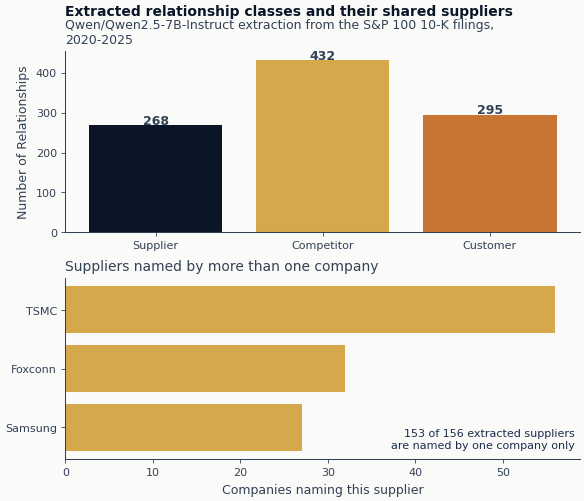

In [31]:
RELATIONSHIP_FIGURE_ALT = (
    f"Two stacked panels. The upper bar chart counts extracted edges by class: "
    f"{competitor_rels} competitor, {customer_rels} customer and {supplier_rels} "
    f"supplier relationships. The lower horizontal bar chart shows the "
    f"{len(shared_suppliers)} suppliers named by more than one company: "
    + ", ".join(
        f"{name} at {len(cs)}"
        for name, cs in sorted(shared_suppliers.items(), key=lambda kv: -len(kv[1]))
    )
    + " companies."
)

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], constrained_layout=True)

# Panel (a): Relationship counts
rel_types = ["Supplier", "Competitor", "Customer"]
rel_counts = [supplier_rels, competitor_rels, customer_rels]
bars = axes[0].bar(rel_types, rel_counts, color=[COLORS["blue"], COLORS["amber"], COLORS["copper"]])
axes[0].set_ylabel("Number of Relationships")
for bar, count in zip(bars, rel_counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(count),
        ha="center",
        fontweight="bold",
    )

# Panel (b): every supplier named by more than one company, not a top-N slice
sorted_shared = sorted(shared_suppliers.items(), key=lambda x: len(x[1]), reverse=True)
names = [s[:20] for s, _ in sorted_shared]
counts = [len(cs) for _, cs in sorted_shared]
axes[1].barh(range(len(names)), counts, color=COLORS["amber"])
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel("Companies naming this supplier")
axes[1].set_title("Suppliers named by more than one company", loc="left")
axes[1].invert_yaxis()
axes[1].text(
    0.99,
    0.05,
    f"{len(suppliers) - len(shared_suppliers)} of {len(suppliers)} extracted suppliers\n"
    "are named by one company only",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color=COLORS["slate"],
)

add_message_title(
    axes[0],
    "Extracted relationship classes and their shared suppliers",
    subtitle=(
        f"{EXTRACTOR_NAME} extraction from the S&P 100 10-K filings, {min(years)}-{max(years)}"
    ),
)
show_with_alt(fig, RELATIONSHIP_FIGURE_ALT)

## 9. Neo4j Batch Loading

Use UNWIND for efficient batch graph loading. UNWIND takes a list parameter and
expands it into rows, allowing a single Cypher statement to create hundreds of
nodes and relationships in one transaction instead of one statement per relationship.

### Batch Loader

Loads all triples to Neo4j in two passes (suppliers, then competitors), using
MERGE to avoid duplicates while only clearing the supply-chain relationships
created by this notebook.

### Batch Query Runner

Execute one UNWIND statement for a homogeneous triple batch and return the
number of relationships loaded.

In [32]:
def run_unwind_batch(session, batch: list[Triple], query: str) -> int:
    """Execute one UNWIND load for a batch of triples."""
    batch_data = [triple.to_dict() for triple in batch]
    session.run(query, batch=batch_data)
    return len(batch)

### UNWIND Templates per Predicate

Each supply-chain predicate has its own MERGE template. Every template merges on
`:Entity {name}` and adds the role as a second label, because a name is one entity
no matter which side of an edge it appears on. Merging on the role label instead
gives Microsoft three separate nodes here: it is a company that files, a supplier
somebody names, and a customer somebody else names.

In [33]:
UNWIND_TEMPLATES: dict[str, str] = {
    "HAS_SUPPLIER": """
        UNWIND $batch AS row
        MERGE (c:Entity {name: row.subject})
        SET c:Company
        MERGE (s:Entity {name: row.object})
        SET s:Supplier
        MERGE (c)-[:HAS_SUPPLIER]->(s)
        """,
    "COMPETES_WITH": """
        UNWIND $batch AS row
        MERGE (c1:Entity {name: row.subject})
        SET c1:Company
        MERGE (c2:Entity {name: row.object})
        SET c2:Company
        MERGE (c1)-[:COMPETES_WITH]->(c2)
        """,
    "HAS_CUSTOMER": """
        UNWIND $batch AS row
        MERGE (c:Entity {name: row.subject})
        SET c:Company
        MERGE (cust:Entity {name: row.object})
        SET cust:Customer
        MERGE (c)-[:HAS_CUSTOMER]->(cust)
        """,
}

### Predicate-Scoped Loader

Run `run_unwind_batch` across every batch of a single predicate's triples.

In [34]:
def _load_predicate(session, triples: list[Triple], predicate: str, batch_size: int) -> int:
    """Load all triples of a single predicate using its UNWIND template."""
    subset = [t for t in triples if t.predicate == predicate]
    loaded = 0
    for batch in batched(subset, batch_size):
        loaded += run_unwind_batch(session, batch, UNWIND_TEMPLATES[predicate])
    return loaded

### Clearing an Existing Graph

This notebook shares a database with the rest of the chapter, and it is the
second writer to touch `:Company`: `08_8k_event_extraction` attaches its event
relationships to nodes with that label and declares `Company.name` unique. So the
reset cannot delete company nodes, and it cannot leave a second node behind for a
name that already exists.

Adopting existing `:Company` nodes into `:Entity` is what prevents the duplicate.
Without it, a database where 08 ran first already holds `(:Company {name: "Apple
Inc."})`, `MERGE (:Entity {name: "Apple Inc."})` matches nothing, and the load
creates a second node that the uniqueness constraint then rejects.

Deleting only entity nodes that have no relationships left is what protects 08:
a `DETACH DELETE` over `:Entity` would take its `APPOINTED` and `ACQUIRED` edges
with it, because after adoption those nodes carry the label too.

In [35]:
RESET_STATEMENTS = (
    # This notebook's own edges, whichever revision wrote them.
    "MATCH (:Company)-[r:HAS_SUPPLIER|COMPETES_WITH|HAS_CUSTOMER]->() DELETE r",
    # One node per name across the chapter: adopt company nodes written by 08, or
    # by an earlier revision of this notebook, before anything merges on :Entity.
    "MATCH (n:Company) WHERE NOT n:Entity SET n:Entity",
    # Role nodes from the revision that keyed on the role label are unreachable now.
    "MATCH (n:Supplier) WHERE NOT n:Entity DETACH DELETE n",
    "MATCH (n:Customer) WHERE NOT n:Entity DETACH DELETE n",
    # Roles are re-applied by the load; a stale one would outlive its edges.
    "MATCH (n:Entity) REMOVE n:Supplier, n:Customer",
    # What is left with no edges at all belongs to no notebook.
    "MATCH (n:Entity) WHERE NOT (n)--() DELETE n",
)

### Top-Level Batch Loader

Reset the supply-chain subgraph, then dispatch each predicate to `_load_predicate`.

In [36]:
def load_to_neo4j_batch(triples: list[Triple], batch_size: int = 1000) -> int:
    """
    Load triples to Neo4j using UNWIND for batch efficiency.

    Returns count of loaded triples.
    """
    if NEO4J_DRIVER is None:
        raise RuntimeError(
            "Neo4j is required for this load step. Start Neo4j and set "
            "NEO4J_URI, NEO4J_USER, and NEO4J_PASSWORD."
        )

    loaded = 0
    with NEO4J_DRIVER.session() as session:
        for statement in RESET_STATEMENTS:
            session.run(statement)
        for predicate in UNWIND_TEMPLATES:
            loaded += _load_predicate(session, triples, predicate, batch_size)

    print(f"Loaded {loaded} triples to Neo4j (batch size: {batch_size})")
    return loaded


print("\n" + "=" * 60)
print("NEO4J BATCH LOADING")
print("=" * 60)

load_start_time = time.time()
loaded_count = load_to_neo4j_batch(unique_triples, batch_size=500)
with NEO4J_DRIVER.session() as session:
    persisted_count = session.run(
        "MATCH (:Company)-[r:HAS_SUPPLIER|COMPETES_WITH|HAS_CUSTOMER]->() RETURN count(r) AS n"
    ).single()["n"]
    persisted_entities = session.run(
        "MATCH (n:Entity) WHERE EXISTS { (n)-[:HAS_SUPPLIER|COMPETES_WITH|HAS_CUSTOMER]-() } "
        "RETURN count(n) AS n"
    ).single()["n"]
assert persisted_count == len(unique_triples), (
    f"Neo4j contains {persisted_count} supply-chain edges; expected {len(unique_triples)}"
)
assert persisted_entities == len(all_entities), (
    f"Neo4j holds {persisted_entities} entity nodes on the supply-chain edges; "
    f"expected {len(all_entities)}. A name that reached the graph twice means "
    "resolution did not collapse it."
)
load_elapsed = time.time() - load_start_time
print(f"Loading completed in {load_elapsed:.2f}s")
print(f"Entity nodes on supply-chain edges: {persisted_entities}, edges: {persisted_count}")


NEO4J BATCH LOADING


Loaded 995 triples to Neo4j (batch size: 500)


Loading completed in 7.24s
Entity nodes on supply-chain edges: 817, edges: 995


### Graph Snapshot

`09_knowledge_graph_features` reads this graph back and needs to know it is reading
what this notebook wrote, not a graph a partial run left behind. Record the identity
here, computed from the graph as Neo4j returns it, so the check downstream compares
two independent reads rather than a constant somebody remembered to update.

The relationship query text is repeated in 09. If either copy drifts, the two reads
order differently and the hash comparison fails, which is the intended outcome.

In [37]:
SNAPSHOT_NAME = "ch23_supply_chain"
RELATIONSHIP_QUERY = """
    CALL () {
        MATCH (c:Company)-[:HAS_SUPPLIER]->(s:Supplier)
        RETURN c.name AS company, 'HAS_SUPPLIER' AS predicate, s.name AS related
        UNION ALL
        MATCH (c:Company)-[:COMPETES_WITH]->(peer:Company)
        RETURN c.name AS company, 'COMPETES_WITH' AS predicate, peer.name AS related
        UNION ALL
        MATCH (c:Company)-[:HAS_CUSTOMER]->(cust:Customer)
        RETURN c.name AS company, 'HAS_CUSTOMER' AS predicate, cust.name AS related
    }
    RETURN company, predicate, related
    ORDER BY company, predicate, related
"""


def read_graph_identity(session) -> tuple[str, dict[str, int], int]:
    """Hash the supply-chain edges as Neo4j returns them, with per-class counts."""
    lines, counts = [], Counter()
    for record in session.run(RELATIONSHIP_QUERY):
        company = " ".join(record["company"].split())
        related = " ".join(record["related"].split())
        lines.append(f"{company}\t{record['predicate']}\t{related}")
        counts[record["predicate"]] += 1
    digest = hashlib.sha256("\n".join(lines).encode()).hexdigest()
    return digest, dict(counts), len(lines)


with NEO4J_DRIVER.session() as session:
    graph_sha256, edge_counts, edge_total = read_graph_identity(session)
    SUPPLY_SNAPSHOT = {
        "name": SNAPSHOT_NAME,
        "graph_sha256": graph_sha256,
        "company_count": len(companies),
        "entity_count": persisted_entities,
        "edge_total": edge_total,
        "supplier_edges": edge_counts.get("HAS_SUPPLIER", 0),
        "competitor_edges": edge_counts.get("COMPETES_WITH", 0),
        "customer_edges": edge_counts.get("HAS_CUSTOMER", 0),
        "cache_content_hash": CACHE_CONTENT_HASH,
        "extractor": EXTRACTOR_NAME,
    }
    session.run("MERGE (s:SupplyGraphSnapshot {name: $s.name}) SET s = $s", s=SUPPLY_SNAPSHOT)

assert edge_total == len(unique_triples), (
    f"the snapshot read {edge_total} edges back; the loader wrote {len(unique_triples)}"
)
assert edge_counts == {
    "HAS_SUPPLIER": supplier_rels,
    "COMPETES_WITH": competitor_rels,
    "HAS_CUSTOMER": customer_rels,
}, f"edge classes read back as {edge_counts}"
print(f"Supply graph snapshot {SNAPSHOT_NAME}: sha256 {graph_sha256[:12]}, {edge_total} edges")

Supply graph snapshot ch23_supply_chain: sha256 ce7a52bf68f1, 995 edges


## 10. Example Queries

Cypher queries for supply chain analysis.

In [38]:
print("\n" + "=" * 60)
print("EXAMPLE CYPHER QUERIES")
print("=" * 60)

queries = {
    "Find all suppliers for a company": """
MATCH (c:Company {name: 'Apple Inc.'})-[:HAS_SUPPLIER]->(s:Supplier)
RETURN s.name AS Supplier ORDER BY s.name
""",
    "Find shared suppliers across multiple companies": """
MATCH (s:Supplier)<-[:HAS_SUPPLIER]-(c:Company)
WITH s, COLLECT(c.name) AS companies, COUNT(c) AS company_count
WHERE company_count > 1
RETURN s.name AS Supplier, company_count, companies
ORDER BY company_count DESC LIMIT 10
""",
    "Find competitor clusters": """
MATCH (c1:Company)-[:COMPETES_WITH]->(c2:Company)
RETURN c1.name AS Company, COLLECT(c2.name) AS Competitors
ORDER BY SIZE(COLLECT(c2.name)) DESC
""",
    "Supply chain risk - single points of failure": """
MATCH (s:Supplier)<-[:HAS_SUPPLIER]-(c:Company)
WITH s, COUNT(c) AS customer_count
WHERE customer_count >= 3
RETURN s.name AS CriticalSupplier, customer_count
ORDER BY customer_count DESC
""",
}

for name, query in queries.items():
    print(f"\n-- {name} --")
    print(query.strip())


EXAMPLE CYPHER QUERIES

-- Find all suppliers for a company --
MATCH (c:Company {name: 'Apple Inc.'})-[:HAS_SUPPLIER]->(s:Supplier)
RETURN s.name AS Supplier ORDER BY s.name

-- Find shared suppliers across multiple companies --
MATCH (s:Supplier)<-[:HAS_SUPPLIER]-(c:Company)
WITH s, COLLECT(c.name) AS companies, COUNT(c) AS company_count
WHERE company_count > 1
RETURN s.name AS Supplier, company_count, companies
ORDER BY company_count DESC LIMIT 10

-- Find competitor clusters --
MATCH (c1:Company)-[:COMPETES_WITH]->(c2:Company)
RETURN c1.name AS Company, COLLECT(c2.name) AS Competitors
ORDER BY SIZE(COLLECT(c2.name)) DESC

-- Supply chain risk - single points of failure --
MATCH (s:Supplier)<-[:HAS_SUPPLIER]-(c:Company)
WITH s, COUNT(c) AS customer_count
WHERE customer_count >= 3
RETURN s.name AS CriticalSupplier, customer_count
ORDER BY customer_count DESC


## 11. Summary Statistics

The two stages are timed separately and never summed. On the cached path the
extraction did not run in this process at all, so a "total pipeline time" would be
the Neo4j load wearing the label of the 27 GPU-minutes that produced the triples.

In [39]:
summary_stats = {
    "Metric": [
        "Companies analyzed",
        "  of which S&P 100 filers",
        "Entity nodes",
        "Total relationships",
        "Supplier relationships",
        "Competitor relationships",
        "Customer relationships",
        "Unique suppliers",
        "Suppliers named by 2+ companies",
        "Suppliers named by 3+ companies",
        "Extraction time (s)",
        "Neo4j load time (s)",
        "Neo4j edges per second",
    ],
    "Value": [
        str(len(companies)),
        str(len(filer_companies)),
        str(persisted_entities),
        str(len(unique_triples)),
        str(supplier_rels),
        str(competitor_rels),
        str(customer_rels),
        str(len(suppliers)),
        str(len(shared_suppliers)),
        str(len([s for s, cs in shared_suppliers.items() if len(cs) >= 3])),
        "not run (cached)" if extraction_elapsed is None else f"{extraction_elapsed:.1f}",
        f"{load_elapsed:.1f}",
        f"{len(unique_triples) / max(load_elapsed, 1e-6):.0f}",
    ],
}

summary_df = pl.DataFrame(summary_stats)
print("\n" + "=" * 60)
print("FINAL STATISTICS")
print("=" * 60)
print(summary_df)


FINAL STATISTICS
shape: (13, 2)
┌─────────────────────────────────┬──────────────────┐
│ Metric                          ┆ Value            │
│ ---                             ┆ ---              │
│ str                             ┆ str              │
╞═════════════════════════════════╪══════════════════╡
│ Companies analyzed              ┆ 106              │
│   of which S&P 100 filers       ┆ 88               │
│ Entity nodes                    ┆ 817              │
│ Total relationships             ┆ 995              │
│ Supplier relationships          ┆ 268              │
│ Competitor relationships        ┆ 432              │
│ Customer relationships          ┆ 295              │
│ Unique suppliers                ┆ 156              │
│ Suppliers named by 2+ companies ┆ 3                │
│ Suppliers named by 3+ companies ┆ 3                │
│ Extraction time (s)             ┆ not run (cached) │
│ Neo4j load time (s)             ┆ 7.2              │
│ Neo4j edges per second        

## 12. Network Visualizations

Three visualization formats:
1. **Static (Book)**: Publication-ready matplotlib figure
2. **Interactive (Notebook)**: pyvis for exploration
3. **Web Export (D3)**: JSON data for website integration

### Trading Applications

The network view describes shared suppliers and competitor clusters. It does not
estimate disruption probabilities or returns; those require separate evidence.

In [40]:
import networkx as nx

### Build NetworkX Graph

Filter to the most connected suppliers and build a NetworkX graph for
visualization. This focuses the network on the supply chain nodes with
highest concentration risk.

In [41]:
def build_networkx_graph(triples: list[Triple], min_companies: int = 2) -> nx.Graph:
    """Build the subgraph of suppliers named by at least `min_companies` companies."""
    G = nx.Graph()

    named_by = {}
    for t in triples:
        if t.predicate == "HAS_SUPPLIER":
            named_by.setdefault(t.object, set()).add(t.subject)

    # A count cut, not a rank cut. Ranking and keeping the top N would fill the
    # figure with arbitrary members of the tie at one company, which is where all
    # but a handful of the extracted suppliers sit.
    kept = {s for s, cs in named_by.items() if len(cs) >= min_companies}

    for t in triples:
        if t.predicate == "HAS_SUPPLIER" and t.object in kept:
            G.add_node(t.subject, node_type="company", label=t.subject[:15])
            G.add_node(t.object, node_type="supplier", count=len(named_by[t.object]))
            G.add_edge(t.subject, t.object, edge_type="supplies")

    return G

In [42]:
# Build the graph
MIN_SHARED_COMPANIES = 2
G = build_networkx_graph(unique_triples, min_companies=MIN_SHARED_COMPANIES)
network_suppliers = [n for n, d in G.nodes(data=True) if d.get("node_type") == "supplier"]
network_companies = [n for n, d in G.nodes(data=True) if d.get("node_type") == "company"]
print(f"Network graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(
    f"{len(network_suppliers)} suppliers named by {MIN_SHARED_COMPANIES}+ companies, "
    f"reaching {len(network_companies)} of the {len(companies)} companies in the graph"
)
assert len(network_suppliers) == len(shared_suppliers), (
    "the network figure and the shared-supplier count disagree"
)

Network graph: 59 nodes, 115 edges
3 suppliers named by 2+ companies, reaching 56 of the 106 companies in the graph


### 12.1 Static Book Figure

Publication-ready matplotlib figure showing supply chain concentration risk.
Suppliers are positioned in an inner ring (sized by connection count), companies
in an outer ring. The most critical supplier is annotated.

In [43]:
import math

from matplotlib.lines import Line2D

# The shared notebook style is initialized by ``utils.style``.

### Static Figure Function

Builds a two-ring layout: suppliers in the inner circle (sized by degree),
companies in the outer ring. Annotates the highest-degree supplier with a
callout showing its dependency count.

### Static Layout Builder

Compute the ring layout once so the plotting function only handles rendering.

In [44]:
def build_static_layout(
    G: nx.Graph,
) -> tuple[list[str], list[str], dict[str, tuple[float, float]], list[str]]:
    """Separate node types and place them on two concentric rings."""
    suppliers = [n for n, d in G.nodes(data=True) if d.get("node_type") == "supplier"]
    companies = [n for n, d in G.nodes(data=True) if d.get("node_type") == "company"]
    pos: dict[str, tuple[float, float]] = {}
    sorted_suppliers = sorted(suppliers, key=lambda x: G.degree(x), reverse=True)
    for i, supplier in enumerate(sorted_suppliers):
        angle = 2 * math.pi * i / len(sorted_suppliers)
        pos[supplier] = (math.cos(angle), math.sin(angle))
    for i, company in enumerate(companies):
        angle = 2 * math.pi * i / len(companies)
        pos[company] = (2.5 * math.cos(angle), 2.5 * math.sin(angle))
    return suppliers, companies, pos, sorted_suppliers

### Static Annotation Helper

Keep the title, legend, and concentration callout in one helper so the main
plotting cell stays concise.

### Static Supplier Callout

Highlight the most connected supplier so the figure immediately communicates
concentration risk.

In [45]:
def add_static_supplier_callout(
    ax: plt.Axes, G: nx.Graph, pos: dict[str, tuple[float, float]], sorted_suppliers: list[str]
) -> None:
    """Annotate the most connected supplier in the static figure."""
    if not sorted_suppliers:
        return
    top = sorted_suppliers[0]
    top_pos = pos[top]
    ax.annotate(
        f"{G.degree(top)} companies\nname this supplier",
        xy=top_pos,
        xytext=(top_pos[0] + 0.8, top_pos[1] + 0.8),
        fontsize=9,
        ha="left",
        arrowprops={"arrowstyle": "->", "color": COLORS["copper"]},
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": COLORS["copper"]},
    )

### Static Legend

Keep the legend handles in a constant so the figure finalizer stays short.

In [46]:
STATIC_LEGEND_HANDLES = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS["blue"],
        markersize=10,
        label="Companies",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS["amber"],
        markersize=14,
        label="Shared suppliers",
    ),
]

### Static Footer

Add the book attribution separately so the annotation helper remains compact.

In [47]:
def add_static_footer(ax: plt.Axes) -> None:
    """Add the ML4T attribution footer."""
    ax.text(
        0.99,
        0.01,
        "ML4T 3rd Edition",
        transform=ax.transAxes,
        fontsize=8,
        ha="right",
        va="bottom",
        color=COLORS["slate"],
        alpha=0.7,
    )

### Static Annotation Helper

Apply the callout, title, legend, and footer after plotting the network.

In [48]:
def finalize_static_figure(
    ax: plt.Axes,
    G: nx.Graph,
    pos: dict[str, tuple[float, float]],
    sorted_suppliers: list[str],
) -> None:
    """Add the supplier callout, title, legend, and footer."""
    add_static_supplier_callout(ax, G, pos, sorted_suppliers)
    add_message_title(
        ax,
        "Suppliers named by several companies, and who names them",
        subtitle=(
            f"{EXTRACTOR_NAME} extraction of S&P 100 10-K excerpts; inner ring sized "
            "by the number of companies naming the supplier"
        ),
    )
    ax.legend(handles=STATIC_LEGEND_HANDLES, loc="upper left", frameon=True)
    add_static_footer(ax)

### Static Figure Function

Render the network using the precomputed layout and then add the annotation
and legend.

In [49]:
def create_static_figure(G: nx.Graph) -> plt.Figure:
    """Create publication-ready supply chain network figure."""
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
    _, companies, pos, sorted_suppliers = build_static_layout(G)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=COLORS["silver_muted"], width=0.8, alpha=0.6)
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=companies,
        ax=ax,
        node_color=COLORS["blue"],
        node_size=80,
        alpha=0.8,
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=sorted_suppliers,
        ax=ax,
        node_color=COLORS["amber"],
        node_size=[100 + G.degree(n) * 20 for n in sorted_suppliers],
        alpha=0.9,
    )
    top_supplier_labels = {n: n for n in sorted_suppliers[:6]}
    nx.draw_networkx_labels(
        G, pos, labels=top_supplier_labels, ax=ax, font_size=7, font_weight="bold"
    )
    finalize_static_figure(ax, G, pos, sorted_suppliers)
    ax.axis("off")
    return fig

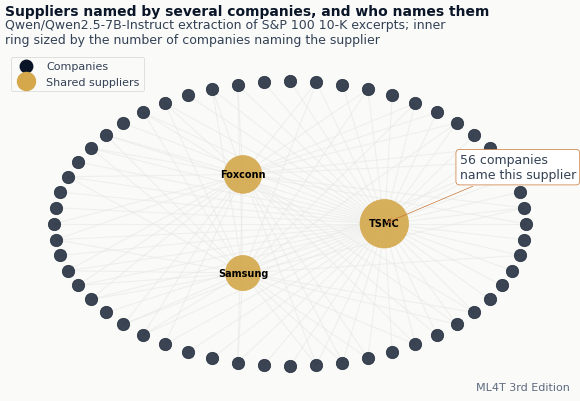

In [50]:
# Render the static figure inline. The publication-quality PNG/PDF
# (figure_23_3_supply_chain_network.*) is generated by the book-repo figure
# scripts, not saved here. Notebooks display figures without writing publication files.
OUTPUT_ROOT = Path(os.getenv("ML4T_OUTPUT_DIR", get_chapter_dir(23) / "output"))
VIZ_DIR = OUTPUT_ROOT / "ch23" / "supply_chain_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

static_fig = create_static_figure(G)
top_shared_name, top_shared_companies = max(shared_suppliers.items(), key=lambda kv: len(kv[1]))
show_with_alt(
    static_fig,
    f"A two-ring network diagram. The inner ring holds the {len(network_suppliers)} "
    f"suppliers named by more than one company, the largest being {top_shared_name} at "
    f"{len(top_shared_companies)} companies. The outer ring holds the "
    f"{len(network_companies)} companies that name at least one of them, each joined "
    "by a line to the suppliers it names.",
)

Larger inner-ring nodes are named by more companies in the extracted candidate
graph. This shared-neighbor structure is directly queryable in a graph
representation. The figure omits every supplier named by a single company, which
is almost all of them, so it shows where the graph has shared structure rather
than what the graph mostly contains. A disruption scenario still needs event
evidence and a model that links exposure to portfolio outcomes.

### 12.2 Interactive Notebook Visualization

pyvis network for interactive exploration (hover, zoom, drag). Nodes display
supplier risk levels (HIGH/MEDIUM/LOW based on dependency count) on hover.

In [51]:
from pyvis.network import Network

### Interactive Graph Builder

Creates a pyvis force-directed graph with tooltips showing concentration risk
levels and supplier details for each node.

### Interactive Node Labels

Use a shared risk classifier so supplier tooltips and the D3 export apply the
same high/medium/low thresholds.

Thresholds on the number of companies naming one supplier. They are cut points for
a display, not a calibrated risk scale: nothing here estimates a disruption
probability, and the counts they read come from what filings happen to name.

In [52]:
RISK_HIGH_COMPANIES = 10
RISK_MEDIUM_COMPANIES = 5


def supplier_risk_level(count: int) -> str:
    """Bucket a supplier by how many companies name it, for notebook displays."""
    if count >= RISK_HIGH_COMPANIES:
        return "HIGH"
    if count >= RISK_MEDIUM_COMPANIES:
        return "MEDIUM"
    return "LOW"

### Interactive Graph Builder

Create the pyvis network with supplier risk tooltips and compact company
labels for notebook exploration.

### Interactive Node Helper

Add one node at a time so the main pyvis builder focuses on orchestration.

In [53]:
def add_interactive_node(net: Network, G: nx.Graph, node: str, data: dict[str, object]) -> None:
    """Add a supplier or company node with its tooltip."""
    if data.get("node_type") == "supplier":
        count = G.degree(node)
        title = (
            f"<b>{node}</b><br>Supplies {count} companies"
            f"<br><i>Concentration risk: {supplier_risk_level(count)}</i>"
        )
        net.add_node(node, label=node, color=COLORS["amber"], size=15 + count * 3, title=title)
        return
    neighbors = list(G.neighbors(node))
    supplier_list = ", ".join(neighbors[:5])
    title = f"<b>{node}</b><br>Key suppliers: {supplier_list}"
    net.add_node(node, label=node[:12], color=COLORS["blue"], size=20, title=title)

### Interactive Edge Helper

Populate the pyvis edge layer separately so the graph builder cell stays short.

In [54]:
def add_interactive_edges(net: Network, G: nx.Graph) -> None:
    """Add the supply edges to the pyvis graph."""
    for u, v in G.edges():
        net.add_edge(u, v, color=COLORS["silver_muted"])

### Interactive Graph Builder

Assemble the pyvis network from the node and edge helpers, then save the HTML
artifact when requested.

In [55]:
def create_interactive_graph(G: nx.Graph, output_path: Path | None = None) -> str | None:
    """Create interactive pyvis visualization."""
    # Build the network inside a temp directory so pyvis doesn't drop a
    # lib/ folder into the repo root (some versions ignore cdn_resources).
    orig_cwd = os.getcwd()
    tmp_dir = tempfile.mkdtemp(prefix="pyvis_")
    try:
        os.chdir(tmp_dir)
        net = Network(
            height="600px",
            width="100%",
            bgcolor="#FAFAF9",
            font_color=COLORS["blue"],
            cdn_resources="remote",  # Use CDN instead of bundling lib/ to CWD
        )
        net.force_atlas_2based()

        for node, data in G.nodes(data=True):
            add_interactive_node(net, G, node, data)
        add_interactive_edges(net, G)

        if output_path:
            html_path = output_path.with_suffix(".html")
            net.save_graph(str(html_path))
            print(f"Saved interactive graph to {html_path.name}")
            return str(html_path)
    finally:
        os.chdir(orig_cwd)

    return None


interactive_path = create_interactive_graph(G, VIZ_DIR / "supply_chain_interactive")

Saved interactive graph to supply_chain_interactive.html


### 12.3 D3.js Web Export

Export graph data as JSON for integration with a D3.js force-directed visualization
on the book's website.

### D3 JSON Exporter

Converts the NetworkX graph into the `{nodes, links, metadata}` format expected
by D3.js force simulations. Includes risk-level annotations per node.

### D3 Node Export

Build a node table with stable integer indices for the D3 force layout.

In [56]:
def build_d3_nodes(G: nx.Graph) -> tuple[list[dict[str, object]], dict[str, int]]:
    """Create D3 nodes plus a stable node index map."""
    nodes = []
    node_index = {}
    for i, (node, data) in enumerate(G.nodes(data=True)):
        node_index[node] = i
        node_type = data.get("node_type", "unknown")
        degree = G.degree(node)
        nodes.append(
            {
                "id": node,
                "group": 1 if node_type == "supplier" else 2,
                "type": node_type,
                "degree": degree,
                # A company's degree counts the suppliers it names, which the
                # supplier thresholds do not describe. Only suppliers get a level.
                "risk_level": (
                    supplier_risk_level(degree).lower() if node_type == "supplier" else None
                ),
            }
        )
    return nodes, node_index

### D3 Link Export

Convert NetworkX edges into the `{source, target, type}` records consumed by
the website visualization.

In [57]:
def build_d3_links(G: nx.Graph, node_index: dict[str, int]) -> list[dict[str, object]]:
    """Create D3 links from the NetworkX edges."""
    links = []
    for u, v, data in G.edges(data=True):
        if u in node_index and v in node_index:
            links.append(
                {
                    "source": node_index[u],
                    "target": node_index[v],
                    "type": data.get("edge_type", "supplies"),
                }
            )
    return links

### D3 Metadata Export

Summarize the graph so the website can show counts and concentration stats.

In [58]:
def build_d3_metadata(
    nodes: list[dict[str, object]], links: list[dict[str, object]]
) -> dict[str, object]:
    """Create metadata for the D3 export."""
    return {
        "total_companies": len([n for n in nodes if n["type"] == "company"]),
        "total_suppliers": len([n for n in nodes if n["type"] == "supplier"]),
        "total_relationships": len(links),
        "high_risk_threshold": RISK_HIGH_COMPANIES,
        "high_risk_suppliers": len(
            [n for n in nodes if n["type"] == "supplier" and n["risk_level"] == "high"]
        ),
        "generated": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

### D3 JSON Exporter

Combine the node, link, and metadata builders into the JSON artifact used by
the website force-directed visualization.

In [59]:
def export_d3_json(G: nx.Graph, output_path: Path) -> dict:
    """Export graph data for D3.js visualization."""
    nodes, node_index = build_d3_nodes(G)
    links = build_d3_links(G, node_index)
    d3_data = {"nodes": nodes, "links": links, "metadata": build_d3_metadata(nodes, links)}
    with open(output_path, "w") as f:
        json.dump(d3_data, f, indent=2)
    print(f"Saved D3 JSON to {output_path.name}")

    return d3_data


d3_data = export_d3_json(G, VIZ_DIR / "supply_chain_d3.json")
print(f"D3 export: {d3_data['metadata']}")

Saved D3 JSON to supply_chain_d3.json
D3 export: {'total_companies': 56, 'total_suppliers': 3, 'total_relationships': 115, 'high_risk_threshold': 10, 'high_risk_suppliers': 3, 'generated': '2026-09-13 00:30:56'}


### 12.4 D3.js HTML Template

Self-contained HTML file with embedded D3 visualization for the book's website.
The template includes CSS styling, a force-directed layout, drag interaction,
and hover tooltips with risk-level coloring. Graph data is injected as inline JSON.

In [60]:
D3_HTML_HEAD = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Supply Chain Knowledge Graph - ML4T</title>
    <script src="https://d3js.org/d3.v7.min.js"></script>
    <style>
        body {
            font-family: 'DM Sans', -apple-system, BlinkMacSystemFont, sans-serif;
            margin: 0;
            padding: 20px;
            background: #FAFAF9;
        }
        h1 {
            color: #0a1628;
            text-align: center;
            margin-bottom: 10px;
        }
        .subtitle {
            color: #1a2d4a;
            text-align: center;
            margin-bottom: 20px;
        }
"""

In [61]:
D3_HTML_HEAD += """
        #graph {
            width: 100%;
            height: 600px;
            border: 1px solid #e8e8e6;
            border-radius: 8px;
            background: white;
        }
        .tooltip {
            position: absolute;
            background: white;
            border: 1px solid #D4A84B;
            border-radius: 4px;
            padding: 10px;
            font-size: 12px;
            pointer-events: none;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
        }
"""

In [62]:
D3_HTML_HEAD += """
        .legend {
            display: flex;
            justify-content: center;
            gap: 30px;
            margin-top: 15px;
        }
        .legend-item {
            display: flex;
            align-items: center;
            gap: 8px;
        }
        .legend-circle {
            width: 16px;
            height: 16px;
            border-radius: 50%;
        }
        .stats {
            text-align: center;
            color: #1a2d4a;
            margin-top: 15px;
            font-size: 14px;
        }
    </style>
</head>
"""

In [63]:
D3_HTML_BODY = """
<body>
    <h1>Supply Chain Concentration Risk</h1>
    <p class="subtitle">Interactive Knowledge Graph from SEC 10-K Filings</p>
    <div id="graph"></div>
    <div class="legend">
        <div class="legend-item">
            <div class="legend-circle" style="background: #D4A84B;"></div>
            <span>Shared suppliers (node size = companies naming them)</span>
        </div>
        <div class="legend-item">
            <div class="legend-circle" style="background: #0a1628;"></div>
            <span>Companies</span>
        </div>
    </div>
    <div class="stats" id="stats"></div>
"""

In [64]:
D3_HTML_SETUP = """
    <script>
    const graphData = GRAPH_DATA_PLACEHOLDER;

    const width = document.getElementById('graph').clientWidth;
    const height = 600;

    const svg = d3.select('#graph')
        .append('svg')
        .attr('width', width)
        .attr('height', height);

    // Color scale
    const color = d3.scaleOrdinal()
        .domain([1, 2])
        .range(['#D4A84B', '#0a1628']);

    // Tooltip
    const tooltip = d3.select('body').append('div')
        .attr('class', 'tooltip')
        .style('opacity', 0);
"""

In [65]:
D3_HTML_FORCES = """
    // Force simulation
    const simulation = d3.forceSimulation(graphData.nodes)
        .force('link', d3.forceLink(graphData.links).id((d, i) => i).distance(80))
        .force('charge', d3.forceManyBody().strength(-200))
        .force('center', d3.forceCenter(width / 2, height / 2))
        .force('collision', d3.forceCollide().radius(d => d.group === 1 ? 10 + d.degree * 2 : 15));

    // Links
    const link = svg.append('g')
        .selectAll('line')
        .data(graphData.links)
        .join('line')
        .attr('stroke', '#e8e8e6')
        .attr('stroke-width', 1.5);
"""

In [66]:
D3_HTML_NODES = """
    // Nodes
    const node = svg.append('g')
        .selectAll('circle')
        .data(graphData.nodes)
        .join('circle')
        .attr('r', d => d.group === 1 ? 8 + d.degree * 2 : 10)
        .attr('fill', d => color(d.group))
        .attr('stroke', '#fff')
        .attr('stroke-width', 1.5)
        .call(drag(simulation))
        .on('mouseover', (event, d) => {
            tooltip.transition().duration(200).style('opacity', .9);
            const riskColor = d.risk_level === 'high' ? '#ef4444' : d.risk_level === 'medium' ? '#D4A84B' : '#10b981';
            tooltip.html(`<strong>${d.id}</strong><br/>
                Type: ${d.type}<br/>
                Connections: ${d.degree}<br/>
                ${d.type === 'supplier' ? `<span style="color:${riskColor}">Risk: ${d.risk_level.toUpperCase()}</span>` : ''}`)
                .style('left', (event.pageX + 10) + 'px')
                .style('top', (event.pageY - 10) + 'px');
        })
        .on('mouseout', () => {
            tooltip.transition().duration(500).style('opacity', 0);
        });
"""

In [67]:
D3_HTML_LABELS = """
    // Labels for high-degree suppliers
    const labels = svg.append('g')
        .selectAll('text')
        .data(graphData.nodes.filter(d => d.group === 1 && d.degree >= 5))
        .join('text')
        .text(d => d.id)
        .attr('font-size', 10)
        .attr('dx', 12)
        .attr('dy', 4)
        .attr('fill', '#1a2d4a');
"""

In [68]:
D3_HTML_DRAG = """
    simulation.on('tick', () => {
        link
            .attr('x1', d => d.source.x)
            .attr('y1', d => d.source.y)
            .attr('x2', d => d.target.x)
            .attr('y2', d => d.target.y);

        node
            .attr('cx', d => d.x = Math.max(20, Math.min(width - 20, d.x)))
            .attr('cy', d => d.y = Math.max(20, Math.min(height - 20, d.y)));

        labels
            .attr('x', d => d.x)
            .attr('y', d => d.y);
    });

    function drag(simulation) {
        return d3.drag()
            .on('start', (event, d) => {
                if (!event.active) simulation.alphaTarget(0.3).restart();
                d.fx = d.x;
                d.fy = d.y;
            })
            .on('drag', (event, d) => {
                d.fx = event.x;
                d.fy = event.y;
            })
            .on('end', (event, d) => {
                if (!event.active) simulation.alphaTarget(0);
                d.fx = null;
                d.fy = null;
            });
    }
"""

In [69]:
D3_HTML_FOOT = """
    // Stats
    document.getElementById('stats').innerHTML =
        `${graphData.metadata.total_companies} companies | ` +
        `${graphData.metadata.total_suppliers} shared suppliers | ` +
        `${graphData.metadata.total_relationships} supply relationships | ` +
        `<strong>${graphData.metadata.high_risk_suppliers} named by ${graphData.metadata.high_risk_threshold}+ companies</strong>`;
    </script>
</body>
</html>
"""

In [70]:
D3_HTML_TEMPLATE = "".join(
    [
        D3_HTML_HEAD,
        D3_HTML_BODY,
        D3_HTML_SETUP,
        D3_HTML_FORCES,
        D3_HTML_NODES,
        D3_HTML_LABELS,
        D3_HTML_DRAG,
        D3_HTML_FOOT,
    ]
)

In [71]:
# Create self-contained HTML with embedded data
html_with_data = D3_HTML_TEMPLATE.replace("GRAPH_DATA_PLACEHOLDER", json.dumps(d3_data))
d3_html_path = VIZ_DIR / "supply_chain_d3.html"
with open(d3_html_path, "w") as f:
    f.write(html_with_data)
print(f"Saved D3 HTML visualization to {d3_html_path.name}")

Saved D3 HTML visualization to supply_chain_d3.html


## 13. Execution Summary

In [72]:
print("\n" + "=" * 60)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 60)
print(f"Triple source: {'cache' if not RERUN_EXTRACTION else 'live extraction'}")
print(f"Extractor: {EXTRACTOR_NAME}")
print(f"Companies: {len(companies)} ({len(filer_companies)} S&P 100 filers)")
print(f"Total relationships: {len(unique_triples)}")
print(f"Most widely named supplier: {top_shared_name} ({len(top_shared_companies)} companies)")
print("\nVisualizations:")
print("  - Static: displayed inline (publication PNG/PDF generated book-side)")
print("  - Interactive: supply_chain_interactive.html")
print("  - D3 web: supply_chain_d3.html")
print("\nReady for Graph RAG integration (03_graph_rag_qa.py)")


NOTEBOOK EXECUTION COMPLETE
Triple source: cache
Extractor: Qwen/Qwen2.5-7B-Instruct
Companies: 106 (88 S&P 100 filers)
Total relationships: 995
Most widely named supplier: TSMC (56 companies)

Visualizations:
  - Static: displayed inline (publication PNG/PDF generated book-side)
  - Interactive: supply_chain_interactive.html
  - D3 web: supply_chain_d3.html

Ready for Graph RAG integration (03_graph_rag_qa.py)


## Key Takeaways

1. **LLMs as KG constructors**: A 7B-parameter model produced candidate
   supplier, customer, and competitor triples from the staged 10-K corpus. The cache
   is provenance-checked, but its edge precision is not established here.

2. **Entity resolution runs on the corpus, not on a lookup table**: the alias map
   printed above rewrites almost nothing, because the extraction prompt already
   asks for short forms. What does the work is the canonical key plus the roster of
   filers the corpus already knows, which is also the only thing that folds a
   company named as a competitor onto the company that filed the 10-K. Both are
   string rules, and a subsidiary named instead of its registrant defeats both.

3. **Batch loading separates graph writes from extraction**: UNWIND sends each
   relationship class in batches. This execution reports both stages without
   treating one graph size as a scaling benchmark.

4. **The shared structure is thin, and the count is the finding**: nearly every
   extracted supplier is named by exactly one company. Ranking suppliers and keeping
   the top dozen hides that, because the twelfth is an arbitrary member of a large
   tie at one company. Cutting on the count instead makes the figure report how much
   shared structure exists.

5. **One name, one node**: merging on the role label rather than the entity gives
   a company that appears as a supplier and as a customer three separate nodes with
   the same name, and every degree computed over them is wrong. The load asserts
   that the node count Neo4j reports equals the number of distinct resolved names.

6. **Graph structure supports relational diagnostics**: Shared-supplier degree is
   directly available once relationships are explicit. A retrieval-only index
   would need a separate relationship layer to answer the same aggregation.

**Next**: See `03_graph_rag_qa` for querying this knowledge graph with natural
language (Graph RAG with text-to-Cypher), and `09_knowledge_graph_features` for
converting graph topology into tabular ML features.

In [73]:
completion_record = {
    "source_filings": filings_df.height,
    "year_min": min(years),
    "year_max": max(years),
    "extractor": EXTRACTOR_NAME,
    "raw_triples": len(all_triples),
    "distinct_raw_names": len(raw_names),
    "candidate_edges": len(unique_triples),
    "supplier_edges": supplier_rels,
    "competitor_edges": competitor_rels,
    "customer_edges": customer_rels,
    "subject_companies": len(companies),
    "filer_companies": len(filer_companies),
    "entity_nodes": persisted_entities,
    "persisted_edges": persisted_count,
    "shared_suppliers": len(shared_suppliers),
    "top_supplier": top_shared_name,
    "top_supplier_degree": len(top_shared_companies),
    "graph_sha256": graph_sha256,
    "llm_loaded": LLM_MODEL is not None,
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))

COMPLETION_RECORD={"candidate_edges": 995, "competitor_edges": 432, "customer_edges": 295, "distinct_raw_names": 1042, "entity_nodes": 817, "extractor": "Qwen/Qwen2.5-7B-Instruct", "filer_companies": 88, "graph_sha256": "ce7a52bf68f18d1a87a09963f93e2a586eafc0a9f154851390395af815351d0e", "llm_loaded": false, "persisted_edges": 995, "raw_triples": 2049, "shared_suppliers": 3, "source_filings": 601, "subject_companies": 106, "supplier_edges": 268, "top_supplier": "TSMC", "top_supplier_degree": 56, "year_max": 2025, "year_min": 2020}
